# Time-Series Forecasting of Carbon Monoxide and Nitrogen Dioxide Levels

Build predictive models to forecast daily or hourly concentrations of **CO(GT)** and **NO₂(GT)** based on historical data.


In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

In [6]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/airquality.csv'
df = pd.read_csv(url)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [7]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='str')

# Project Workflow

### **Deliverables**:
1. **Forecasting Models**:
   - Trained models for `CO(GT)` and `NO₂(GT)`.
2. **Forecast Visualization**:
   - Plots showing historical trends and future predictions.
3. **Evaluation Report**:
   - Metrics and comparison of different forecasting models.
4. **Insights and Recommendations**:
   - Suggestions for mitigating high levels of these gases based on predictions.


### 1. Data Preprocessing
- **Date-Time Parsing**:
  - Combine the `Date` and `Time` columns into a single `datetime` column.
  - Set the `datetime` column as the index of the dataset.
- **Resampling**:
  - Aggregate the data into meaningful time intervals (e.g., hourly or daily averages).
- **Handle Missing Values**:
  - Use interpolation, mean, or advanced imputation techniques to fill missing data for `CO(GT)` and `NO₂(GT)`.
- **Outlier Detection**:
  - Remove or cap extreme values in `CO(GT)` and `NO₂(GT)` using statistical thresholds.

In [8]:
# copy dataframe for date and time concatenation 
df_dt = df.copy()

In [9]:
df_dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


In [10]:
# Adding Date and time 
df_dt['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])
df_dt.set_index('datetime', inplace=True)
df_dt.index = pd.to_datetime(df_dt.index)
df_dt.index.name = 'datetime'

# Drop date and time columns
df_dt.drop(['Date', 'Time'], axis=1, inplace=True)
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [11]:
def aggregation(col_name):
    return df_dt[col_name].resample('d').mean()

print(aggregation('CO(GT)'))
print(aggregation('NO2(GT)'))

datetime
2004-03-10     1.966667
2004-03-11    -6.187500
2004-03-12   -14.095833
2004-03-13    -5.750000
2004-03-14    -5.966667
                ...    
2005-03-31     1.387500
2005-04-01    -7.270833
2005-04-02     0.854167
2005-04-03     1.141667
2005-04-04   -11.393333
Freq: D, Name: CO(GT), Length: 391, dtype: float64
datetime
2004-03-10    108.833333
2004-03-11     87.375000
2004-03-12     89.916667
2004-03-13    105.583333
2004-03-14     97.458333
                 ...    
2005-03-31    100.708333
2005-04-01    107.333333
2005-04-02    100.166667
2005-04-03    111.125000
2005-04-04    122.000000
Freq: D, Name: NO2(GT), Length: 391, dtype: float64


In [12]:
print(f'CO variable type : {df_dt['CO(GT)'].dtype}')
print(f'NO2 variable type : {df_dt['NO2(GT)'].dtype}')
print(f'T variable type : {df_dt['T'].dtype}')

CO variable type : float64
NO2 variable type : int64
T variable type : float64


In [13]:
def set_null():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].mask(df_dt[i] == -200, np.nan)

set_null()
df_dt.to_csv("airquality_replace_missing_value_66.csv")

In [14]:
# count total missing values
# count cosecutive missing values
def count_missing_val(col_name_cosec):
    is_na = df_dt[col_name_cosec].isna()
    max_strek = 0
    current_strek = 0

    for i in is_na:
        if i == True:
            current_strek += 1
            if current_strek > max_strek:
                max_strek = current_strek
        else:
            current_strek = 0

    return print(f'Total missing values (nan) of {col_name_cosec} : {df_dt[col_name_cosec].isna().sum()}\nMaximum Consecutive Missing for {col_name_cosec}: {max_strek}')

In [15]:
count_missing_val('CO(GT)')

Total missing values (nan) of CO(GT) : 1683
Maximum Consecutive Missing for CO(GT): 173


In [16]:
count_missing_val('NO2(GT)')

Total missing values (nan) of NO2(GT) : 1642
Maximum Consecutive Missing for NO2(GT): 173


In [17]:
# function for detecting gap of consecutive missing values
def measure_missing_val_gap(col_name_gap, consec_missing_val):
    is_na = df_dt[col_name_gap].isna()
    start = None
    count = 0
    for idx, val in is_na.items():
        if val:
            if start is None:
                start = idx
            count += 1
        else:
            if count == consec_missing_val:
                return print(f'{col_name_gap} - Gap Start : {start}\n{col_name_gap} - Gap End : {prev_idx}')
            start = None
            count = 0

        prev_idx = idx


measure_missing_val_gap('CO(GT)', 173)
print('-----------------------------------------')
measure_missing_val_gap('NO2(GT)', 173)


CO(GT) - Gap Start : 2004-10-13 11:00:00
CO(GT) - Gap End : 2004-10-20 15:00:00
-----------------------------------------
NO2(GT) - Gap Start : 2004-10-13 11:00:00
NO2(GT) - Gap End : 2004-10-20 15:00:00


In [18]:
# function for deleting consecutive missing values
def delete_consecutive_missing_val(col_name, df, threshold):

    is_missing = df[col_name].isna()

    current_streak = 0
    gap_start = None
    drop_index_list = []

    for t, miss in is_missing.items():
        if miss:
            if current_streak == 0:
                gap_start = t
            current_streak += 1
            gap_end = t
        else:
            if current_streak > threshold:
                drop_index_list.extend(df.loc[gap_start:gap_end].index)
            current_streak = 0
            gap_start = None

    if current_streak > threshold:
        drop_index_list.extend(df.loc[gap_start:gap_end].index)

    dropped = len(drop_index_list)
    df_new = df.drop(drop_index_list)

    print(f'{col_name} Consecutive Missing values - Dropped rows : {dropped}')
    return df_new

df_dt = delete_consecutive_missing_val('CO(GT)', df_dt, 24)
df_dt = delete_consecutive_missing_val('NO2(GT)', df_dt, 24)

CO(GT) Consecutive Missing values - Dropped rows : 1357
NO2(GT) Consecutive Missing values - Dropped rows : 148


In [19]:
# replace missing values of all features by Time Interpolation
def set_time_interpolate():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].interpolate(method='time')

set_time_interpolate()
df_dt.to_csv('airquality_test_1099.csv')

In [20]:
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [34]:
# Remove extreme values (Outlier)
def outlier_removal(col_name):
    outlier = []
    key_outlier = []
    global df_dt

    q1 = np.percentile(df_dt[col_name], 25)
    q3 = np.percentile(df_dt[col_name], 75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    for key, i in enumerate (df_dt[col_name]):
        if i < lower_bound or i > upper_bound :
            outlier.append(i)
            key_outlier.append(key)

    print(f'Outliers : {outlier}')
    print(f'Outliers key : {key_outlier}')
    df_dt = df_dt.drop(df_dt.index[key_outlier])


In [36]:
outlier_removal('CO(GT)')

Outliers : []
Outliers key : []


In [38]:
outlier_removal('NO2(GT)')

Outliers : []
Outliers key : []


### 2. Exploratory Data Analysis (EDA)
- **Trend Analysis**:
  - Visualize the long-term trends of `CO(GT)` and `NO₂(GT)`.
- **Seasonality**:
  - Identify seasonal patterns (e.g., daily or yearly fluctuations).
- **Correlation Analysis**:
  - Explore relationships between `CO(GT)`, `NO₂(GT)`, and other features (e.g., temperature or humidity).


The NO₂(GT) time series shows a clear upward trend over time, indicating a gradual increase in pollution levels. In contrast, CO(GT) does not exhibit a strong long-term trend but shows significant short-term fluctuations, suggesting variability without consistent growth.

Trend Analysis

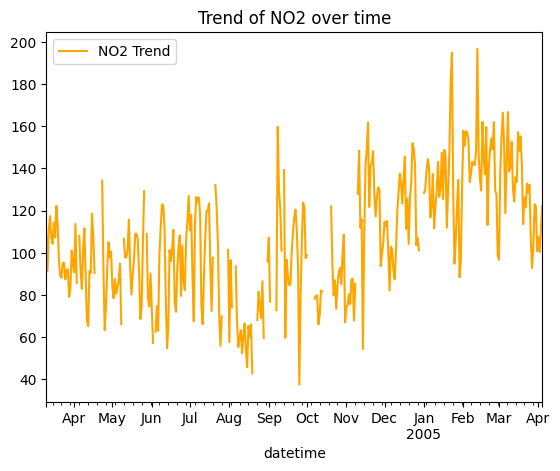

In [39]:
# Trend Analysis
# df_dt['CO(GT)'].rolling(window=24).mean().plot(label='CO Trend')
df_dt['NO2(GT)'].resample('D').mean().plot(label='NO2 Trend', color='orange')
plt.legend()
plt.title('Trend of NO2 over time')
plt.show()

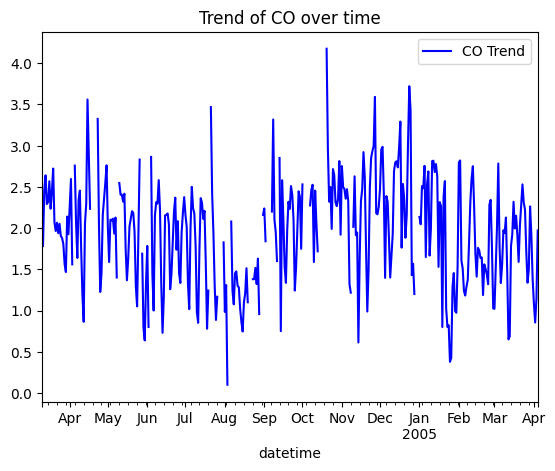

In [41]:
df_dt['CO(GT)'].resample('D').mean().plot(label='CO Trend', color='blue')
plt.legend()
plt.title('Trend of CO over time')
plt.show()

Seasonality Test

<Axes: xlabel='datetime'>

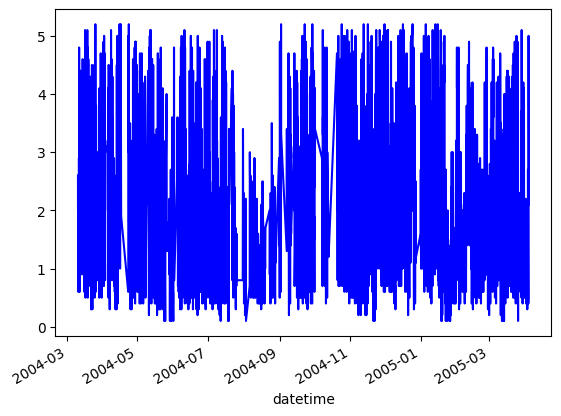

In [42]:
df_dt['CO(GT)'].plot(label='CO Seasonality Trend', color='blue')

<Axes: xlabel='datetime'>

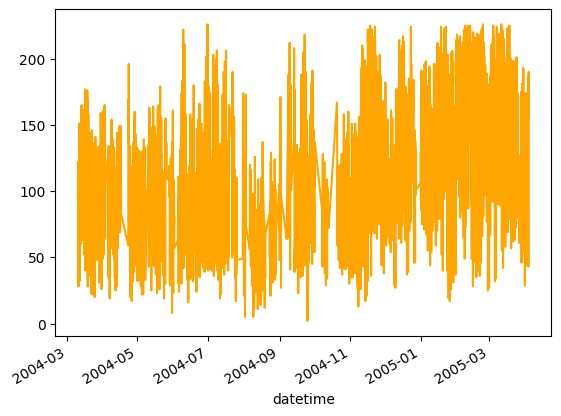

In [43]:
df_dt['NO2(GT)'].plot(label='NO2 Seasonality Trend', color='orange')

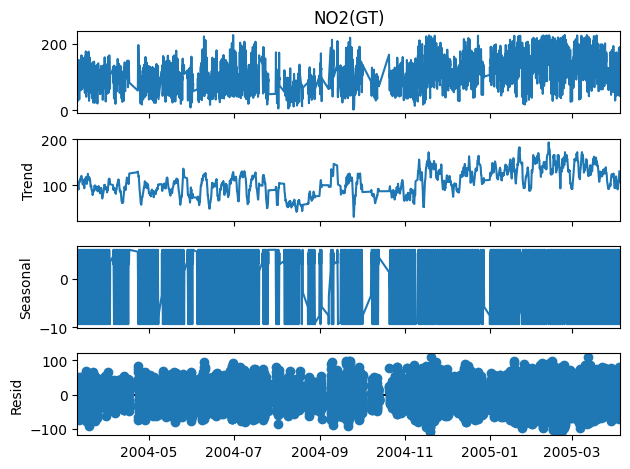

In [44]:
# seasonal decompossition graph for NO2
season_no2 = seasonal_decompose(df_dt['NO2(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

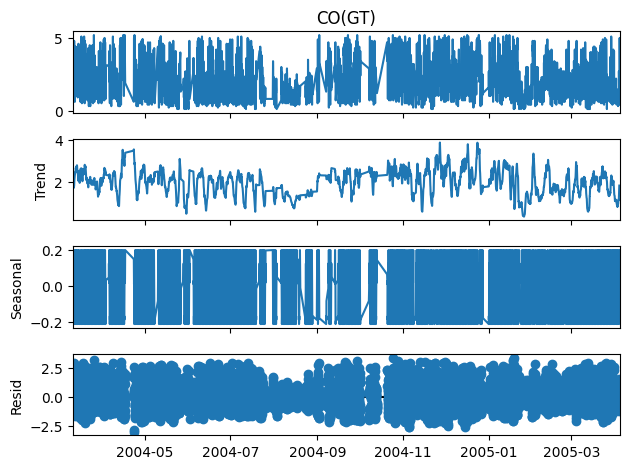

In [45]:
# seasonal decompossition graph for CO
season_no2 = seasonal_decompose(df_dt['CO(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

Correlation Analysis

In [46]:
# correlation analysis with respect to CO 
def corr_analysis(col_name):
    corr_of_co = df_dt.corr()[col_name].sort_values(ascending=False)
    return pd.DataFrame(corr_of_co)

corr_analysis('CO(GT)')

,CO(GT)
CO(GT),1.000000
PT08.S2(NMHC),0.884637
C6H6(GT),0.882226
PT08.S1(CO),0.836814
PT08.S5(O3),0.812020
NOx(GT),0.741803
NO2(GT),0.686620
PT08.S4(NO2),0.581368
NMHC(GT),0.264553
T,0.086478


In [47]:
# correlation analysis with respect to NO2
corr_analysis('NO2(GT)')

,NO2(GT)
NO2(GT),1.000000
NOx(GT),0.740109
CO(GT),0.686620
PT08.S5(O3),0.671809
PT08.S2(NMHC),0.617432
PT08.S1(CO),0.616779
C6H6(GT),0.583448
NMHC(GT),0.182468
PT08.S4(NO2),0.103580
RH,-0.141671



### 3. Feature Engineering
- Create lag features for `CO(GT)` and `NO₂(GT)` to incorporate historical values.
- Add time-based features (e.g., hour of the day, day of the week, month).
- Include environmental factors (`T`, `RH`, `AH`) as predictors.


Autocorrelation Plots (ACF)

In [48]:
# ACF Plot 
def acf_plot(col_name):
    plot_acf(df_dt[col_name].dropna(), lags=40)
    return plt.show()


CO(GT) ACF Plot : 


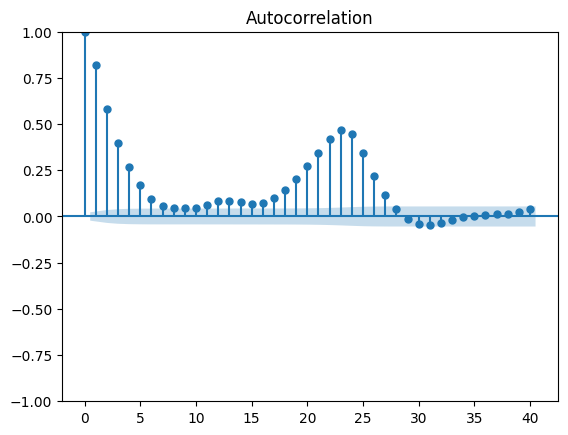

NO2(GT) ACF Plot : 


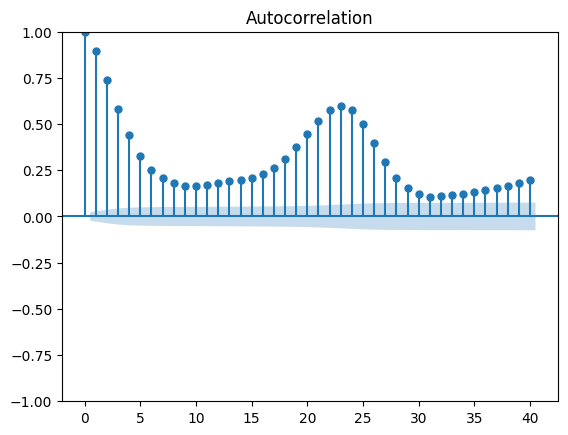

In [49]:
# acf plots for CO and NO2
print('CO(GT) ACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) ACF Plot : ')
acf_plot('NO2(GT)')

Partial Autocorrelation Plot (PACF)

In [ ]:
def pacf_plot(col_name):
    plot_pacf(df_dt[col_name].dropna(), lags=40)
    return plt.show()

CO(GT) PACF Plot : 


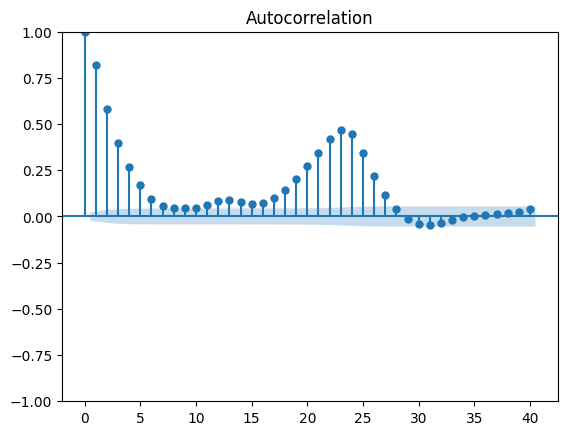

NO2(GT) PACF Plot : 


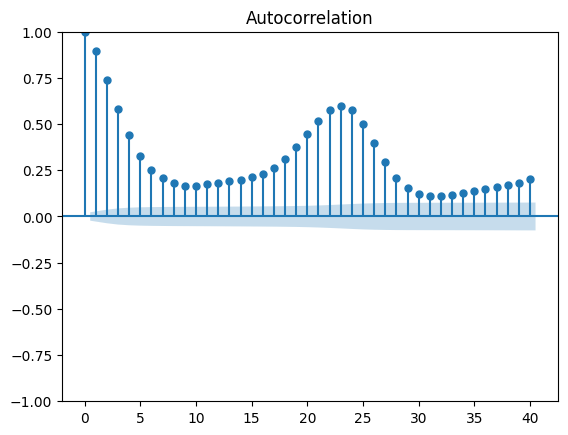

In [111]:
# pacf plots for CO and NO2

print('CO(GT) PACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) PACF Plot : ')
acf_plot('NO2(GT)')

In [ ]:
# function of lag features
def lag_feature(lag_name, col_name, lag_shift):
    df_dt[lag_name] = df_dt[col_name].shift(lag_shift)


In [67]:
# add lag features in CO 
lag_feature('CO_lag_1', 'CO(GT)', 1)
lag_feature('CO_lag_2', 'CO(GT)', 2)
lag_feature('CO_lag_3', 'CO(GT)', 3)
lag_feature('CO_lag_24', 'CO(GT)', 24)

# add lag features in NO2
lag_feature('NO2_lag_1', 'NO2(GT)', 1)
lag_feature('NO2_lag_2', 'NO2(GT)', 2)
lag_feature('NO2_lag_3', 'NO2(GT)', 3)
lag_feature('NO2_lag_24', 'NO2(GT)', 24)

df_dt = df_dt.dropna()
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO_lag_1,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-12 21:00:00,4.4,1598.0,333.0,20.1,1299.0,274.0,752.0,149.0,1941.0,1627.0,12.1,53.3,0.7536,3.7,3.9,2.4,4.8,145.0,149.0,119.0,151.0
2004-03-12 22:00:00,3.5,1484.0,215.0,14.3,1127.0,253.0,839.0,139.0,1723.0,1491.0,11.0,59.1,0.7740,4.4,3.7,3.9,3.9,149.0,145.0,149.0,136.0
2004-03-13 00:00:00,2.7,1280.0,122.0,9.6,964.0,193.0,963.0,113.0,1544.0,1285.0,9.5,64.1,0.7597,3.5,4.4,3.7,1.5,139.0,149.0,145.0,85.0
2004-03-13 01:00:00,1.9,1196.0,67.0,7.4,873.0,139.0,1071.0,97.0,1463.0,1144.0,9.1,63.9,0.7423,2.7,3.5,4.4,1.0,113.0,139.0,149.0,53.0
2004-03-13 02:00:00,1.6,1184.0,43.0,5.4,782.0,83.0,1176.0,82.0,1365.0,1043.0,8.8,63.9,0.7256,1.9,2.7,3.5,1.7,97.0,113.0,139.0,97.0


In [72]:
# time based features
df_dt['hour'] = df_dt.index.hour
df_dt['day_of_week'] = df_dt.index.dayofweek
df_dt['month'] = df_dt.index.month

df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO_lag_1,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24,hour,day_of_week,month
datetime,,,,,,,,,,,,,,,,,,,,,,,,
2004-03-12 21:00:00,4.4,1598.0,333.0,20.1,1299.0,274.0,752.0,149.0,1941.0,1627.0,12.1,53.3,0.7536,3.7,3.9,2.4,4.8,145.0,149.0,119.0,151.0,21,4,3
2004-03-12 22:00:00,3.5,1484.0,215.0,14.3,1127.0,253.0,839.0,139.0,1723.0,1491.0,11.0,59.1,0.7740,4.4,3.7,3.9,3.9,149.0,145.0,149.0,136.0,22,4,3
2004-03-13 00:00:00,2.7,1280.0,122.0,9.6,964.0,193.0,963.0,113.0,1544.0,1285.0,9.5,64.1,0.7597,3.5,4.4,3.7,1.5,139.0,149.0,145.0,85.0,0,5,3
2004-03-13 01:00:00,1.9,1196.0,67.0,7.4,873.0,139.0,1071.0,97.0,1463.0,1144.0,9.1,63.9,0.7423,2.7,3.5,4.4,1.0,113.0,139.0,149.0,53.0,1,5,3
2004-03-13 02:00:00,1.6,1184.0,43.0,5.4,782.0,83.0,1176.0,82.0,1365.0,1043.0,8.8,63.9,0.7256,1.9,2.7,3.5,1.7,97.0,113.0,139.0,97.0,2,5,3


In [110]:
df_dt.to_csv('dataset_clean.csv')

In [109]:
# feature selection for X and Y split for CO(GT)
X_of_co = df_dt[['T', 'RH', 'AH', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_24', 'hour', 'day_of_week', 'month']]
y_of_co = df_dt['CO(GT)']

X_of_co.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 7397 entries, 2004-03-12 21:00:00 to 2005-04-04 14:00:00
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T            7397 non-null   float64
 1   RH           7397 non-null   float64
 2   AH           7397 non-null   float64
 3   CO_lag_1     7397 non-null   float64
 4   CO_lag_2     7397 non-null   float64
 5   CO_lag_3     7397 non-null   float64
 6   CO_lag_24    7397 non-null   float64
 7   hour         7397 non-null   int32  
 8   day_of_week  7397 non-null   int32  
 9   month        7397 non-null   int32  
dtypes: float64(7), int32(3)
memory usage: 549.0 KB


In [108]:
# feature selection for X and Y split for NO2(GT)
X_of_no2 = df_dt[['T', 'RH', 'AH', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_2', 'hour', 'day_of_week', 'month']]
y_of_no2 = df_dt['NO2(GT)']

X_of_no2.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7397 entries, 2004-03-12 21:00:00 to 2005-04-04 14:00:00
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T            7397 non-null   float64
 1   RH           7397 non-null   float64
 2   AH           7397 non-null   float64
 3   NO2_lag_1    7397 non-null   float64
 4   NO2_lag_2    7397 non-null   float64
 5   NO2_lag_3    7397 non-null   float64
 6   NO2_lag_2    7397 non-null   float64
 7   hour         7397 non-null   int32  
 8   day_of_week  7397 non-null   int32  
 9   month        7397 non-null   int32  
dtypes: float64(7), int32(3)
memory usage: 549.0 KB


### 4. Time-Series Forecasting
- Train separate models for **CO(GT)** and **NO₂(GT)**.
- Explore the following forecasting approaches:
  - **Statistical Models**:
    - Classical models like ARIMA or SARIMA for univariate forecasting.
  - **Machine Learning Models**:
    - Use regression models trained on lag features and external predictors.
  - **Deep Learning Models**:
    - Apply LSTM, GRU, or other RNN-based models for sequence forecasting.
- Evaluate and compare the models.


Seasonal Auto Regressive Moving Average (SARIMA)

In [ ]:
# Augmented Dickey-Fuller Test (p Value measurment)
def adf_test(col_name):
    result = adfuller(df_dt[col_name].dropna())
    if result[1] <= 0.05:
        print(f'{col_name} is Stationary with p Value = {result}')
    else:
        print(f'{col_name} is Non-Stationary with p Value = {result}')

result_n = adfuller(df_dt['CO(GT)'].dropna())
print(result_n)
adf_test('CO(GT)')
adf_test('NO2(GT)')

CO(GT) is Stationary with p Value = (np.float64(-10.047913989500758), np.float64(1.438000721084561e-17), 34, 7362, {'1%': np.float64(-3.4312385603847475), '5%': np.float64(-2.8619326753401544), '10%': np.float64(-2.566979016782658)}, np.float64(13564.635445611544))
NO2(GT) is Stationary with p Value = (np.float64(-7.0808922950680175), np.float64(4.669638467644791e-10), 26, 7370, {'1%': np.float64(-3.4312375955324748), '5%': np.float64(-2.8619322490133428), '10%': np.float64(-2.566978789842572)}, np.float64(63065.26137821452))


### 5. Model Evaluation
- Use appropriate metrics for forecasting:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Percentage Error (MAPE)
- Plot actual vs. predicted values to visualize performance.


### 6. Visualization and Insights
- Generate forecasts for future dates and visualize the trends.
- Highlight seasonal patterns, peak times, and periods of concern.
- Provide actionable recommendations based on predicted trends.

